# 01 — Data Audit & Preprocessing
**Project:** DustiniaDelixia Groceria — Customer Experience Analysis  
**Persona:** Customer Experience Analyst  

**Urutan eksekusi:**
0. Setup & Paths  
1. Dataset Overview  
2. [PRE-CHECK] Multiline Row Fix — review_orders.csv  
3. Null Analysis — kolom kritis  
4. Duplicate Analysis  
5. Order Status Distribution  
6. Review Score Distribution & Monthly Trend  
7. Review Comment Coverage → H5 Gate Decision  
8. Delivery Timestamps & Delay Distribution  
9. Join Integrity Check  
10. Save Base Analytical Dataset  
11. Summary & Decisions


## 0. Setup & Paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, io, warnings

warnings.filterwarnings("ignore")

# ── Path auto-detection ──────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DOCS           = ROOT / "docs"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DOCS.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Data raw     : {DATA_RAW}")
print(f"Raw CSVs     : {sorted([f.name for f in DATA_RAW.glob('*.csv')])}")


Matplotlib is building the font cache; this may take a moment.


Project root : D:\.py\Oprec Admin MCI 2026\dustinia-cx-analysis
Data raw     : D:\.py\Oprec Admin MCI 2026\dustinia-cx-analysis\data\raw
Raw CSVs     : ['category_translation.csv', 'closed_deals.csv', 'customers.csv', 'geolocation.csv', 'mql.csv', 'order_items.csv', 'order_payments.csv', 'order_reviews.csv', 'orders.csv', 'products.csv', 'sellers.csv']


In [2]:
# ── Plot style ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

PALETTE_SCORE = {1: "#d62728", 2: "#ff7f0e", 3: "#bcbd22", 4: "#17becf", 5: "#2ca02c"}
COLOR_LATE    = "#d62728"
COLOR_ONTIME  = "#2ca02c"
COLOR_PRIMARY = "#4C72B0"


## 1. Dataset Overview

Load semua file CSV dan tampilkan ringkasan shape, null count, dan memory.  
**Note:** `order_reviews.csv` dimuat via safe loader di section berikutnya.


In [3]:
FILES = {
    "orders"              : "orders.csv",
    "order_items"         : "order_items.csv",
    "order_payments"      : "order_payments.csv",
    "customers"           : "customers.csv",
    "products"            : "products.csv",
    "sellers"             : "sellers.csv",
    "geolocation"         : "geolocation.csv",
    "category_translation": "category_translation.csv",
    "mql"                 : "mql.csv",
    "closed_deals"        : "closed_deals.csv",
}

dfs = {}
for name, fname in FILES.items():
    path = DATA_RAW / fname
    if path.exists():
        dfs[name] = pd.read_csv(path)
        print(f"  ✅  {name:<25} {len(dfs[name]):>8,} rows  {dfs[name].shape[1]} cols")
    else:
        print(f"  ⚠️   {name:<25} FILE NOT FOUND — {path}")


  ✅  orders                      99,441 rows  8 cols
  ✅  order_items                112,650 rows  7 cols
  ✅  order_payments             103,886 rows  5 cols
  ✅  customers                   99,441 rows  5 cols
  ✅  products                    32,951 rows  9 cols
  ✅  sellers                      3,095 rows  4 cols
  ✅  geolocation               1,000,163 rows  5 cols
  ✅  category_translation            71 rows  2 cols
  ✅  mql                          8,000 rows  4 cols
  ✅  closed_deals                   842 rows  14 cols


In [4]:
# ── Summary table (non-review tables) ──────────────────────────
rows_summary = []
for name, df in dfs.items():
    rows_summary.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : df.shape[1],
        "total_nulls": int(df.isnull().sum().sum()),
        "duplicates" : int(df.duplicated().sum()),
        "memory_MB"  : round(df.memory_usage(deep=True).sum() / 1e6, 2),
    })

summary_df = pd.DataFrame(rows_summary).sort_values("rows", ascending=False).reset_index(drop=True)
display(summary_df.style
    .format({"rows": "{:,}", "total_nulls": "{:,}", "duplicates": "{:,}", "memory_MB": "{:.2f}"})
    .bar(subset=["rows"], color="#AED6F1")
    .bar(subset=["total_nulls"], color="#F1948A")
    .set_caption("Dataset Overview (order_reviews loaded separately in Section 2)")
)


,table,rows,columns,total_nulls,duplicates,memory_MB
0,geolocation,"1,000,163",5,0,"261,831",153.18
1,order_items,"112,650",7,0,0,41.34
2,order_payments,"103,886",5,0,0,18.68
3,orders,"99,441",8,"4,908",0,61.83
4,customers,"99,441",5,0,0,31.06
5,products,"32,951",9,"2,448",0,7.12
6,mql,"8,000",4,60,0,2.49
7,sellers,"3,095",4,0,0,0.69
8,closed_deals,842,14,"3,300",0,0.68
9,category_translation,71,2,0,0,0.01


## 2. Null Analysis — Kolom Kritis

Fokus pada kolom yang langsung mempengaruhi feasibility hipotesis:

| Kolom | Hipotesis yang terdampak |
|---|---|
| `order_delivered_customer_date` | H1 (delivery delay) |
| `order_estimated_delivery_date` | H1 |
| `review_comment_message` | H5 (TF-IDF) |
| `product_category_name` | H3 |
| `customer_state` | H4 |
| `seller_id` | H2 |


In [10]:
# ── Null per kolom, semua tabel ─────────────────────────────────
null_records = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            null_records.append({
                "table"    : name,
                "column"   : col,
                "null_count": n,
                "null_pct" : round(n / len(df) * 100, 2),
            })

null_df = (pd.DataFrame(null_records)
           .sort_values(["table", "null_pct"], ascending=[True, False]).reset_index(drop=True))
null_df.index = range(1, len(null_df) + 1)

display(null_df.style
    .format({"null_count": "{:,}", "null_pct": "{:.2f}%"})
    .bar(subset=["null_pct"], color="#F1948A", vmax=100)
    .set_caption("Null columns across all tables")
)


,table,column,null_count,null_pct
1,closed_deals,has_company,779,92.52%
2,closed_deals,has_gtin,778,92.40%
3,closed_deals,average_stock,776,92.16%
4,closed_deals,declared_product_catalog_size,773,91.81%
5,closed_deals,lead_behaviour_profile,177,21.02%
6,closed_deals,business_type,10,1.19%
7,closed_deals,lead_type,6,0.71%
8,closed_deals,business_segment,1,0.12%
9,mql,origin,60,0.75%
10,order_reviews,review_comment_title,"87,656",88.34%


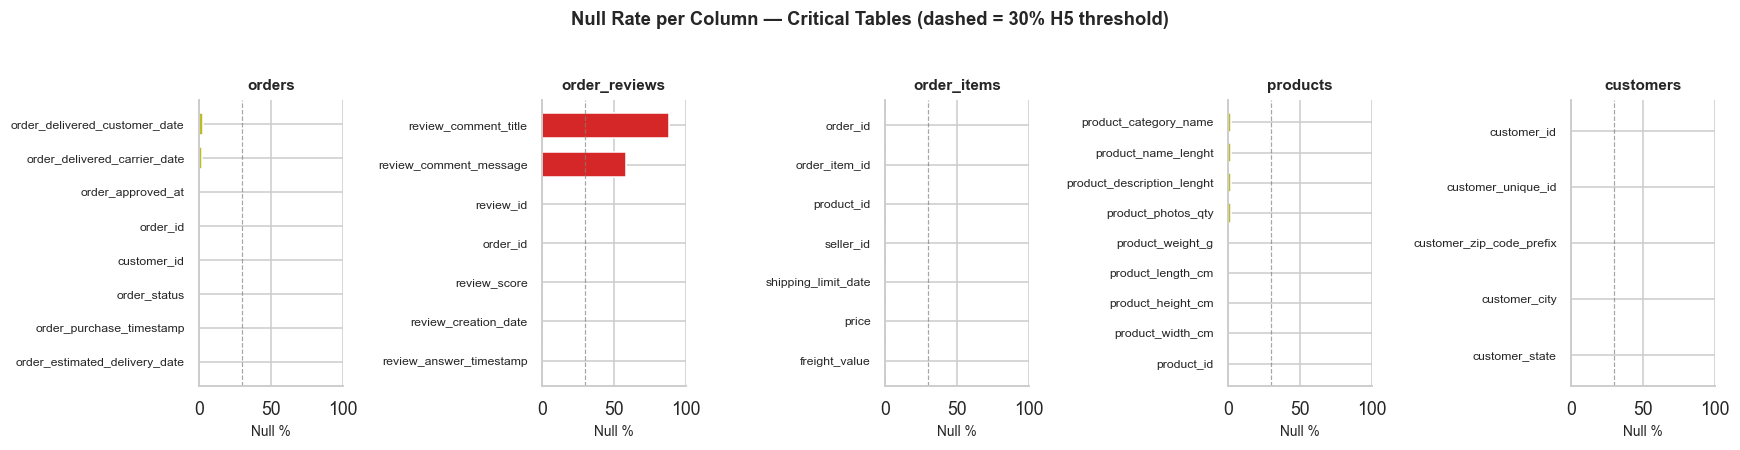

Legend:  Red >50%  |  Orange 10–50%  |  Yellow 0–10%  |  Green 0%


In [11]:
# ── Heatmap null rate — tabel critical ──────────────────────────
critical = ["orders", "order_reviews", "order_items", "products", "customers"]
fig, axes = plt.subplots(1, len(critical), figsize=(16, 4))

for ax, name in zip(axes, critical):
    df = dfs[name]
    null_pcts = (df.isnull().mean() * 100).sort_values(ascending=False)
    colors = [
        "#d62728" if v > 50 else
        "#ff7f0e" if v > 10 else
        "#bcbd22" if v > 0  else
        "#2ca02c"
        for v in null_pcts.values
    ]
    ax.barh(null_pcts.index[::-1], null_pcts.values[::-1],
            color=colors[::-1], height=0.65)
    ax.set_xlim(0, 100)
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Null %", fontsize=9)
    ax.axvline(30, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Null Rate per Column — Critical Tables (dashed = 30% H5 threshold)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Legend:  Red >50%  |  Orange 10–50%  |  Yellow 0–10%  |  Green 0%")


## 3. Duplicate & Gap Analysis

Tiga area kritikal:
1. **order_reviews** — bisa ada >1 review per `order_id` (Olist mengizinkan re-review)
2. **customers** — `customer_unique_id` duplikat → repeat buyers, jangan salah hitung
3. **geolocation** — zip prefix muncul berkali-kali, normal tapi perlu dihandle saat join
4. **category_translation** — pastikan semua `product_category_name` ada ter-cover


In [12]:
# ── 3a. Reviews per order ────────────────────────────────────────
rev_per_order = reviews.groupby("order_id")["review_id"].count()
dup_orders    = rev_per_order[rev_per_order > 1]

print("[order_reviews] Multiple reviews per order_id:")
print(f"  Total reviews             : {len(reviews):,}")
print(f"  Unique order_ids          : {reviews['order_id'].nunique():,}")
print(f"  Orders with >1 review     : {len(dup_orders):,} ({len(dup_orders)/reviews['order_id'].nunique()*100:.2f}%)")
print(f"  Max reviews per order     : {rev_per_order.max()}")
print()
for k, v in rev_per_order.value_counts().sort_index().items():
    print(f"    {k} review(s) → {v:,} orders")

print("\n  ➜ Resolution: keep LATEST review per order_id")
print("    (sort by review_answer_timestamp DESC, drop_duplicates on order_id, keep='first')")


[order_reviews] Multiple reviews per order_id:
  Total reviews             : 99,224
  Unique order_ids          : 98,673
  Orders with >1 review     : 547 (0.55%)
  Max reviews per order     : 3

    1 review(s) → 98,126 orders
    2 review(s) → 543 orders
    3 review(s) → 4 orders

  ➜ Resolution: keep LATEST review per order_id
    (sort by review_answer_timestamp DESC, drop_duplicates on order_id, keep='first')


In [13]:
# ── 3b. Repeat buyers ───────────────────────────────────────────
customers = dfs["customers"]
cust_counts = customers.groupby("customer_unique_id")["customer_id"].count()
repeat      = cust_counts[cust_counts > 1]

print("[customers] customer_id vs customer_unique_id:")
print(f"  Total rows (customer_id)       : {len(customers):,}")
print(f"  Unique customers (unique_id)   : {customers['customer_unique_id'].nunique():,}")
print(f"  Repeat buyers (≥2 orders)      : {len(repeat):,} ({len(repeat)/customers['customer_unique_id'].nunique()*100:.2f}%)")
print()
for k, v in cust_counts.value_counts().sort_index().head(8).items():
    if k >= 2:
        print(f"    {k} orders: {v:,} customers")
print("\n  ➜ Use customer_unique_id for true unique customer counts")
print("    customer_id is ORDER-scoped (new per purchase), not PERSON-scoped")


[customers] customer_id vs customer_unique_id:
  Total rows (customer_id)       : 99,441
  Unique customers (unique_id)   : 96,096
  Repeat buyers (≥2 orders)      : 2,997 (3.12%)

    2 orders: 2,745 customers
    3 orders: 203 customers
    4 orders: 30 customers
    5 orders: 8 customers
    6 orders: 6 customers
    7 orders: 3 customers
    9 orders: 1 customers

  ➜ Use customer_unique_id for true unique customer counts
    customer_id is ORDER-scoped (new per purchase), not PERSON-scoped


In [14]:
# ── 3c. Geolocation duplicates ──────────────────────────────────
geo = dfs["geolocation"]
geo_total = len(geo)
geo_dups  = geo.duplicated().sum()
unique_zips = geo["geolocation_zip_code_prefix"].nunique()

print("[geolocation]")
print(f"  Total rows              : {geo_total:,}")
print(f"  Duplicate exact rows    : {geo_dups:,} ({geo_dups/geo_total*100:.1f}%)")
print(f"  Unique zip prefixes     : {unique_zips:,}")
print(f"  Avg entries per prefix  : {geo_total/unique_zips:.1f}")
print("\n  ➜ Not used in primary H1–H5 analysis.")
print("    If needed for H4 map viz: aggregate lat/lng by mean per zip prefix.")


[geolocation]
  Total rows              : 1,000,163
  Duplicate exact rows    : 261,831 (26.2%)
  Unique zip prefixes     : 19,015
  Avg entries per prefix  : 52.6

  ➜ Not used in primary H1–H5 analysis.
    If needed for H4 map viz: aggregate lat/lng by mean per zip prefix.


In [28]:
# ── 3d. Category translation gap check ──────────────────────────────────

products    = dfs["products"]
cat_trans   = dfs["category_translation"]

prod_cats   = set(products["product_category_name"].dropna().unique())
mapped_cats = set(cat_trans["product_category_name"].unique())

unmapped = prod_cats - mapped_cats
missing_in_prod = mapped_cats - prod_cats  # ada di terjemahan tapi tidak ada di produk

print(f"[Category Translation Gap Check]")
print(f"  Kategori unik di products          : {len(prod_cats)}")
print(f"  Entri di category_translation      : {len(mapped_cats)}")
print(f"  Gap (ada di products, tidak mapped): {len(unmapped)}")
print(f"  Tidak terpakai di translation      : {len(missing_in_prod)}")

if unmapped:
    print(f"\n  ⚠️  Kategori yang BELUM ada terjemahannya:")
    for cat in sorted(unmapped):
        n_products  = (products["product_category_name"] == cat).sum()
        print(f"     '{cat}'  →  {n_products:,} produk terdampak")
else:
    print("\n  ✅ Semua kategori sudah terpetakan.")

# Simulasi: berapa baris yang akan hilang kalau dibiarkan?
if unmapped:
    rows_affected = products[products["product_category_name"].isin(unmapped)].shape[0]
    pct_affected  = rows_affected / len(products) * 100
    print(f"\n  Jika dibiarkan: {rows_affected:,} baris produk ({pct_affected:.2f}%)")
    print(f"  akan menghasilkan NULL di kolom english name saat join.")
    print(f"  H3 akan diam-diam kehilangan baris ini tanpa error.")

[Category Translation Gap Check]
  Kategori unik di products          : 73
  Entri di category_translation      : 71
  Gap (ada di products, tidak mapped): 2
  Tidak terpakai di translation      : 0

  ⚠️  Kategori yang BELUM ada terjemahannya:
     'pc_gamer'  →  3 produk terdampak
     'portateis_cozinha_e_preparadores_de_alimentos'  →  10 produk terdampak

  Jika dibiarkan: 13 baris produk (0.04%)
  akan menghasilkan NULL di kolom english name saat join.
  H3 akan diam-diam kehilangan baris ini tanpa error.


## 4. Order Status Distribution

**Mengapa penting sebelum analisis delivery?**  
`order_delivered_customer_date` hanya meaningful untuk status `delivered`.  
Analisis H1 harus difilter ke status ini — tanpa filter, delay calculation  
akan menghasilkan NaT/NaN yang bias.


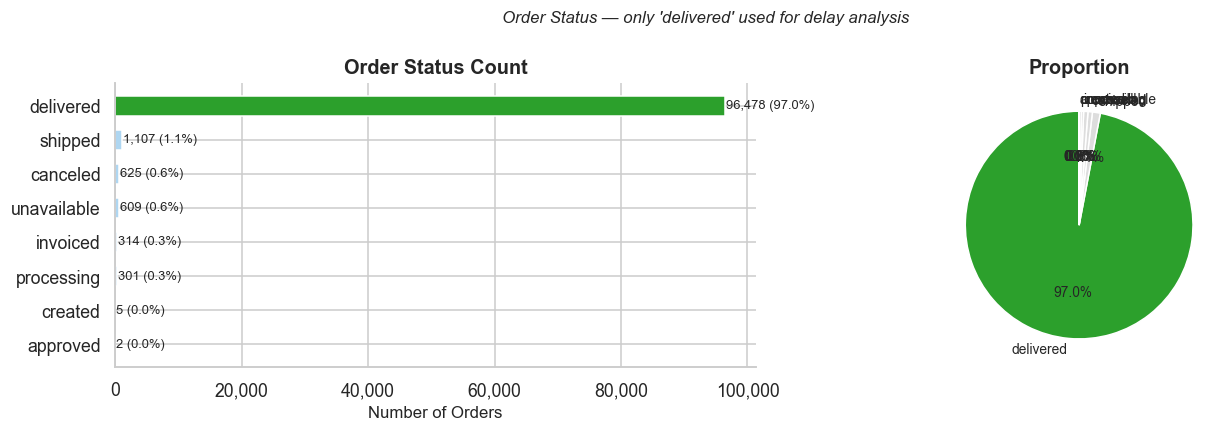

Retained for H1 (delivered) : 96,478 / 99,441  (97.0%)
Excluded                    : 2,963  (3.0%)


In [15]:
orders = dfs["orders"].copy()
status_counts = orders["order_status"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Bar
colors_bar = ["#2ca02c" if s == "delivered" else "#AED6F1" for s in status_counts.index]
bars = ax1.barh(status_counts.index[::-1], status_counts.values[::-1],
                color=colors_bar[::-1], height=0.6)
ax1.set_xlabel("Number of Orders")
ax1.set_title("Order Status Count", fontweight="bold")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, val in zip(bars, status_counts.values[::-1]):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"{val:,} ({val/len(orders)*100:.1f}%)", va="center", fontsize=8.5)

# Pie
colors_pie = ["#2ca02c" if s == "delivered" else "#dddddd" for s in status_counts.index]
ax2.pie(status_counts.values, labels=status_counts.index,
        colors=colors_pie, autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 9})
ax2.set_title("Proportion", fontweight="bold")

plt.suptitle("Order Status — only 'delivered' used for delay analysis",
             fontsize=11, style="italic")
plt.tight_layout()
plt.show()

delivered_n = status_counts.get("delivered", 0)
total_n     = len(orders)
print(f"Retained for H1 (delivered) : {delivered_n:,} / {total_n:,}  ({delivered_n/total_n*100:.1f}%)")
print(f"Excluded                    : {total_n - delivered_n:,}  ({(total_n-delivered_n)/total_n*100:.1f}%)")


## 5. Review Score Distribution & Monthly Trend

**Dua pertanyaan bisnis yang dijawab section ini:**
1. Bagaimana distribusi skor sekarang? (berapa persen negatif, netral, positif)
2. Apakah ada tren kenaikan historis — atau benar-benar stagnan seperti yang CEO khawatirkan?


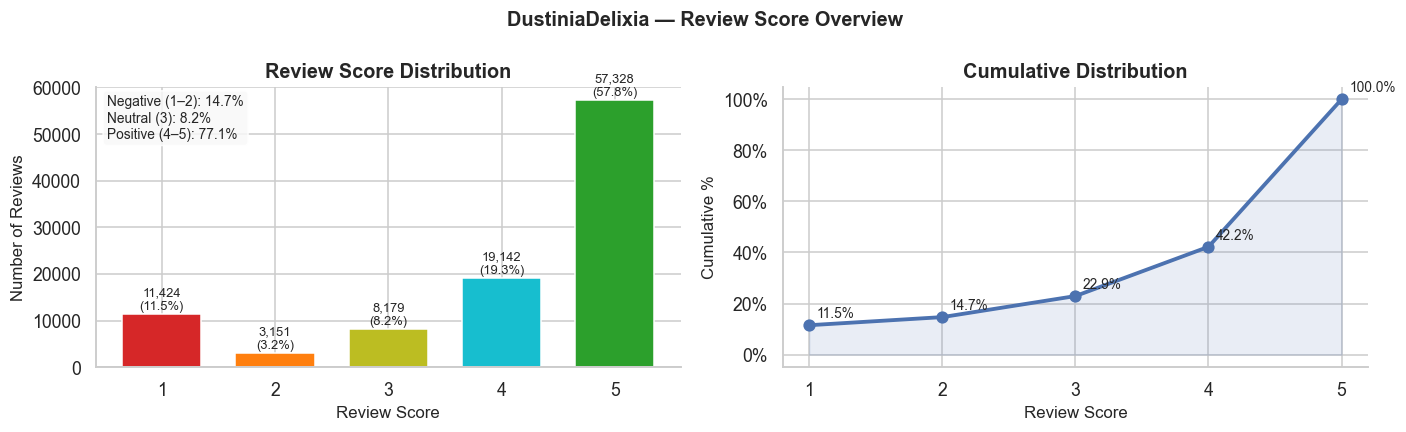

In [27]:
score_counts = reviews["review_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Bar distribusi ───────────────────────────────────────────────
bar_colors = [PALETTE_SCORE[int(s)] for s in score_counts.index]
bars = axes[0].bar(score_counts.index.astype(int), score_counts.values,
                   color=bar_colors, edgecolor="white", width=0.7)
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Review Score Distribution", fontweight="bold")
axes[0].set_xticks([1, 2, 3, 4, 5])

for bar, (score, count) in zip(bars, score_counts.items()):
    pct = count / score_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8.5)

total = score_counts.sum()
neg = score_counts.reindex([1,2], fill_value=0).sum()
neu = score_counts.get(3, 0)
pos = score_counts.reindex([4,5], fill_value=0).sum()
axes[0].text(0.02, 0.97,
    f"Negative (1–2): {neg/total*100:.1f}%\nNeutral (3): {neu/total*100:.1f}%\nPositive (4–5): {pos/total*100:.1f}%",
    transform=axes[0].transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f8f8f8", alpha=0.85))

# ── Cumulative distribution ──────────────────────────────────────
cumulative = score_counts.sort_index().cumsum() / total * 100
axes[1].plot(cumulative.index.astype(int), cumulative.values,
             marker="o", color=COLOR_PRIMARY, linewidth=2.5, markersize=7)
axes[1].fill_between(cumulative.index.astype(int), cumulative.values,
                     alpha=0.12, color=COLOR_PRIMARY)
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Cumulative %")
axes[1].set_title("Cumulative Distribution", fontweight="bold")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for x, y in zip(cumulative.index.astype(int), cumulative.values):
    axes[1].annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                     xytext=(5, 5), fontsize=9)

plt.suptitle("DustiniaDelixia — Review Score Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


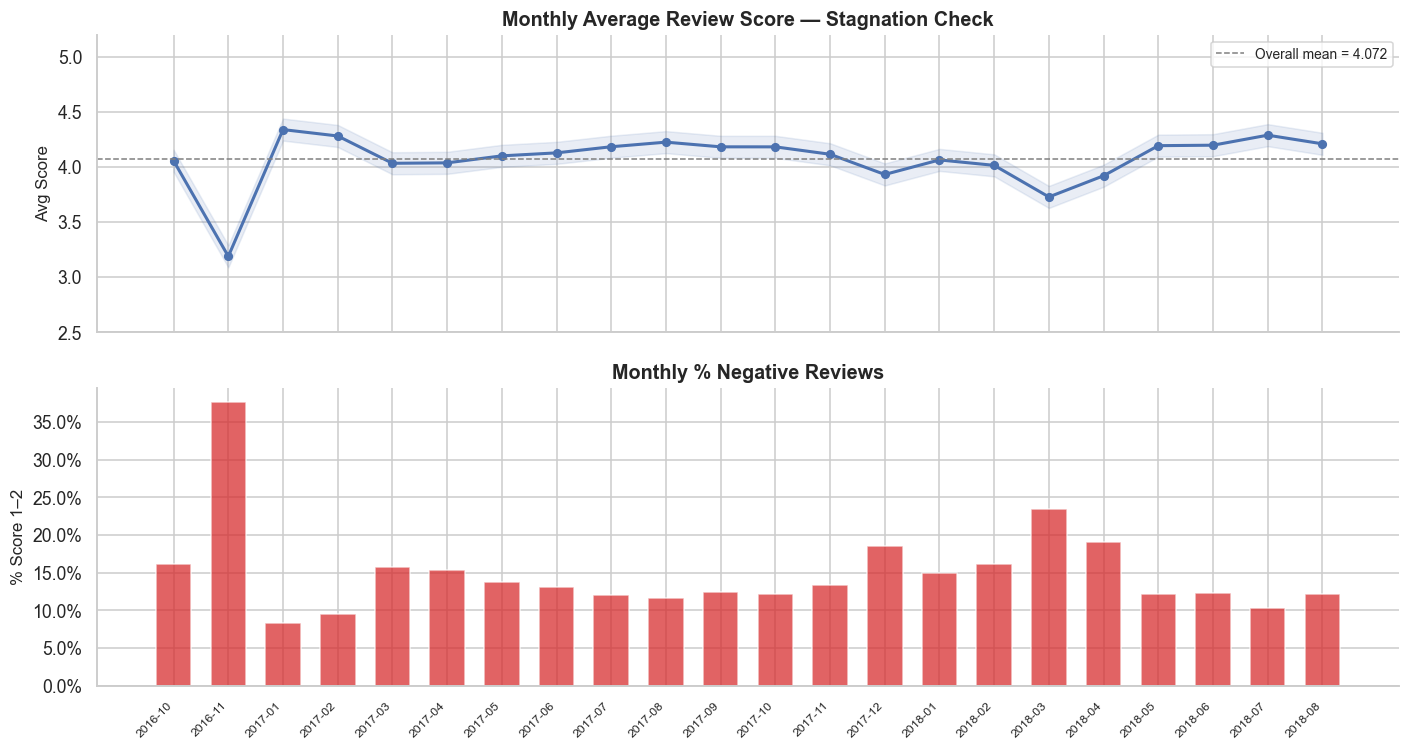

Score range : 3.188 – 4.339
Worst month : 2016-11  avg=3.188  n=101
Best month  : 2017-01   avg=4.339  n=239


In [17]:
# ── Monthly trend — stagnation check ────────────────────────────
reviews_ts = reviews.copy()
reviews_ts["review_creation_date"] = pd.to_datetime(
    reviews_ts["review_creation_date"], errors="coerce")
reviews_ts["year_month"] = reviews_ts["review_creation_date"].dt.to_period("M")

monthly = (reviews_ts.groupby("year_month")
    .agg(
        avg_score   = ("review_score", "mean"),
        median_score= ("review_score", "median"),
        n_reviews   = ("review_score", "count"),
        pct_negative= ("review_score", lambda x: (x <= 2).mean() * 100)
    )
    .reset_index())

monthly = monthly[monthly["n_reviews"] >= 50].copy()  # exclude sparse months
monthly["ym_str"] = monthly["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Avg score
axes[0].plot(monthly["ym_str"], monthly["avg_score"],
             marker="o", color=COLOR_PRIMARY, linewidth=2, markersize=5)
axes[0].axhline(monthly["avg_score"].mean(), color="gray", linestyle="--",
                linewidth=1, label=f"Overall mean = {monthly['avg_score'].mean():.3f}")
axes[0].set_ylim(2.5, 5.2)
axes[0].set_ylabel("Avg Score")
axes[0].set_title("Monthly Average Review Score — Stagnation Check", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].fill_between(monthly["ym_str"],
    monthly["avg_score"] - 0.1, monthly["avg_score"] + 0.1,
    alpha=0.12, color=COLOR_PRIMARY)

# % negative
axes[1].bar(monthly["ym_str"], monthly["pct_negative"],
            color=COLOR_LATE, alpha=0.72, width=0.65)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylabel("% Score 1–2")
axes[1].set_title("Monthly % Negative Reviews", fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

worst = monthly.loc[monthly["avg_score"].idxmin()]
best  = monthly.loc[monthly["avg_score"].idxmax()]
print(f"Score range : {monthly['avg_score'].min():.3f} – {monthly['avg_score'].max():.3f}")
print(f"Worst month : {worst['ym_str']}  avg={worst['avg_score']:.3f}  n={worst['n_reviews']:,}")
print(f"Best month  : {best['ym_str']}   avg={best['avg_score']:.3f}  n={best['n_reviews']:,}")


## 6. Review Comment Coverage — H5 Gate Decision

**Decision rule (dari project_plan.md):**

| Coverage score 1–2 | Keputusan |
|---|---|
| ≥ 30% | TF-IDF pada `review_comment_message` |
| 10–29% | Fallback ke `review_comment_title` |
| < 10% | Drop H5 — dokumentasikan sebagai data limitation |


In [20]:
cov_rows = []
for score in [1, 2, 3, 4, 5]:
    sub = reviews[reviews["review_score"] == score]
    cov_rows.append({
        "score"       : int(score),
        "n_total"     : len(sub),
        "msg_filled"  : int(sub["review_comment_message"].notna().sum()),
        "msg_pct"     : sub["review_comment_message"].notna().mean() * 100,
        "title_filled": int(sub["review_comment_title"].notna().sum()),
        "title_pct"   : sub["review_comment_title"].notna().mean() * 100,
    })

cov_df = pd.DataFrame(cov_rows)

# Score 1+2 combined row
low = reviews[reviews["review_score"] <= 2]
combined_row = {
    "score"       : "1+2",
    "n_total"     : len(low),
    "msg_filled"  : int(low["review_comment_message"].notna().sum()),
    "msg_pct"     : low["review_comment_message"].notna().mean() * 100,
    "title_filled": int(low["review_comment_title"].notna().sum()),
    "title_pct"   : low["review_comment_title"].notna().mean() * 100,
}
cov_df = pd.concat([cov_df, pd.DataFrame([combined_row])], ignore_index=True)
cov_df.index = range(1, len(cov_df) + 1)

display(cov_df.style
    .format({"n_total": "{:,}", "msg_filled": "{:,}", "msg_pct": "{:.1f}%",
             "title_filled": "{:,}", "title_pct": "{:.1f}%"})
    .bar(subset=["msg_pct", "title_pct"], color="#AED6F1", vmax=100)
    .set_caption("Review comment coverage by score")
)


,score,n_total,msg_filled,msg_pct,title_filled,title_pct
1,1,"11,424","8,745",76.5%,"1,873",16.4%
2,2,"3,151","2,145",68.1%,478,15.2%
3,3,"8,179","3,557",43.5%,824,10.1%
4,4,"19,142","5,976",31.2%,"1,735",9.1%
5,5,"57,328","20,554",35.9%,"6,658",11.6%
6,1+2,"14,575","10,890",74.7%,"2,351",16.1%


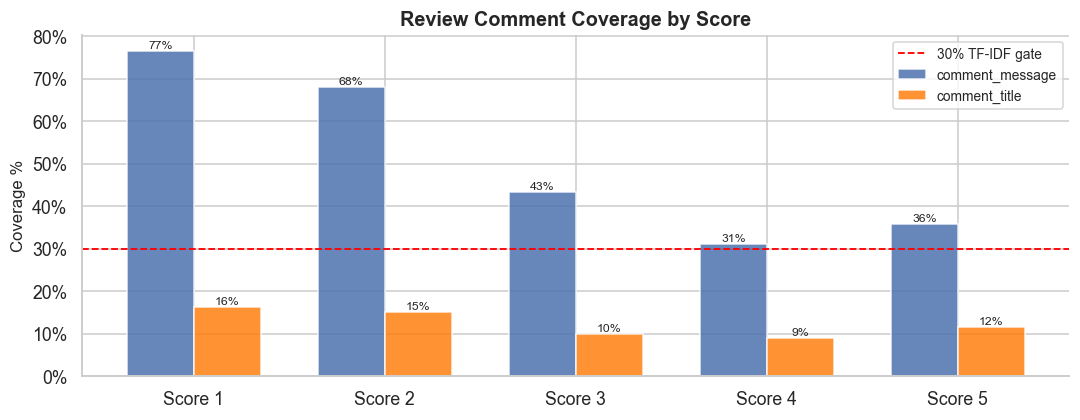


  H5 GATE DECISION
  Score 1–2 comment_message coverage : 74.7%
  Available corpus size              : 10,890 reviews

  ✅ TF-IDF VIABLE
     → Use review_comment_message for score 1–2 subset
     → Proceed to 03_text_analysis.ipynb

  H5_DECISION = 'tfidf'  ← copy to decisions.md


In [21]:
# ── Visualisasi coverage ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(5)
w = 0.35
labels = [f"Score {s}" for s in [1,2,3,4,5]]
msg_pcts   = cov_df[cov_df["score"].isin([1,2,3,4,5])]["msg_pct"].values
title_pcts = cov_df[cov_df["score"].isin([1,2,3,4,5])]["title_pct"].values

ax.bar(x - w/2, msg_pcts,   w, label="comment_message", color=COLOR_PRIMARY, alpha=0.85)
ax.bar(x + w/2, title_pcts, w, label="comment_title",   color="#ff7f0e",     alpha=0.85)

for i, v in enumerate(msg_pcts):
    ax.text(i - w/2, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)
for i, v in enumerate(title_pcts):
    ax.text(i + w/2, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)

ax.axhline(30, color="red", linestyle="--", linewidth=1.2, label="30% TF-IDF gate")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Coverage %")
ax.set_title("Review Comment Coverage by Score", fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

# ── Decision ────────────────────────────────────────────────────
combined_msg_pct = float(cov_df[cov_df["score"] == "1+2"]["msg_pct"].values[0])
combined_n       = int(cov_df[cov_df["score"] == "1+2"]["msg_filled"].values[0])

print(f"\n{'='*52}")
print(f"  H5 GATE DECISION")
print(f"{'='*52}")
print(f"  Score 1–2 comment_message coverage : {combined_msg_pct:.1f}%")
print(f"  Available corpus size              : {combined_n:,} reviews")
print()
if combined_msg_pct >= 30:
    print("  ✅ TF-IDF VIABLE")
    print("     → Use review_comment_message for score 1–2 subset")
    print("     → Proceed to 03_text_analysis.ipynb")
    H5_DECISION = "tfidf"
elif combined_msg_pct >= 10:
    print("  ⚠️  USE TITLE FALLBACK")
    print("     → TF-IDF pada review_comment_title")
    H5_DECISION = "title_fallback"
else:
    print("  ❌ DROP H5")
    print("     → Coverage too low — document as data limitation")
    print("     → Recommend primary research as future action")
    H5_DECISION = "drop"

print(f"\n  H5_DECISION = '{H5_DECISION}'  ← copy to decisions.md")


## 7. Delivery Timestamps & Delay Distribution

**Preview sebelum korelasi penuh di notebook 02.**

Formula:  
`delivery_delay_days = order_delivered_customer_date − order_estimated_delivery_date`

- Negatif = tiba lebih awal dari estimasi ✅  
- Positif = terlambat ❌


In [22]:
orders_ts = dfs["orders"].copy()
delivered = orders_ts[orders_ts["order_status"] == "delivered"].copy()

for col in ["order_delivered_customer_date", "order_estimated_delivery_date",
            "order_purchase_timestamp"]:
    delivered[col] = pd.to_datetime(delivered[col], errors="coerce")

delivered["delivery_delay_days"] = (
    delivered["order_delivered_customer_date"] -
    delivered["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivered["is_late"] = (delivered["delivery_delay_days"] > 0).astype(int)
valid_delay = delivered.dropna(subset=["delivery_delay_days"])

print("[Delivery Delay Stats]")
desc = valid_delay["delivery_delay_days"].describe(
    percentiles=[.05, .1, .25, .5, .75, .9, .95, .99])
for stat, val in desc.items():
    flag = "  ← LATE THRESHOLD" if stat == "50%" and val > 0 else ""
    print(f"  {stat:<8}: {val:>8.2f} days{flag}")

late_n   = (valid_delay["delivery_delay_days"] > 0).sum()
ontime_n = (valid_delay["delivery_delay_days"] <= 0).sum()
print(f"\n  On time / early : {ontime_n:,}  ({ontime_n/len(valid_delay)*100:.1f}%)")
print(f"  Late (>0 days)  : {late_n:,}  ({late_n/len(valid_delay)*100:.1f}%)")


[Delivery Delay Stats]
  count   : 96470.00 days
  mean    :   -11.18 days
  std     :    10.18 days
  min     :  -146.02 days
  5%      :   -25.94 days
  10%     :   -21.29 days
  25%     :   -16.24 days
  50%     :   -11.95 days
  75%     :    -6.39 days
  90%     :    -1.14 days
  95%     :     3.82 days
  99%     :    18.94 days
  max     :   188.98 days

  On time / early : 88,644  (91.9%)
  Late (>0 days)  : 7,826  (8.1%)


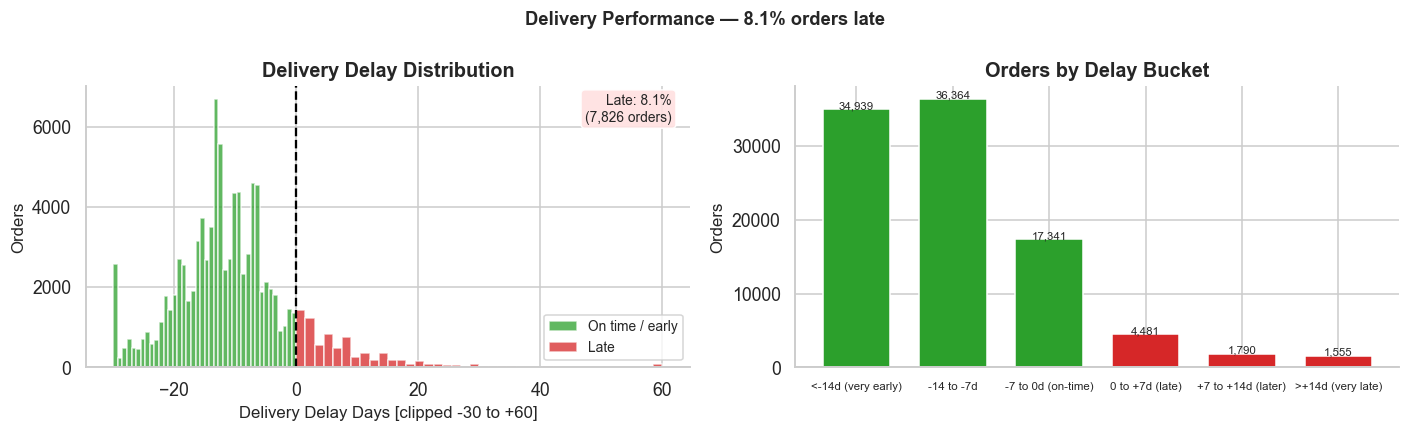

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Histogram ───────────────────────────────────────────────────
delay_clipped = valid_delay["delivery_delay_days"].clip(-30, 60)
early_vals = delay_clipped[delay_clipped <= 0]
late_vals  = delay_clipped[delay_clipped > 0]

axes[0].hist(early_vals, bins=40, color=COLOR_ONTIME, alpha=0.75,
             label="On time / early", edgecolor="white")
axes[0].hist(late_vals, bins=40, color=COLOR_LATE, alpha=0.75,
             label="Late", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Delivery Delay Days [clipped -30 to +60]")
axes[0].set_ylabel("Orders")
axes[0].set_title("Delivery Delay Distribution", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].text(0.97, 0.97,
    f"Late: {late_n/len(valid_delay)*100:.1f}%\n({late_n:,} orders)",
    transform=axes[0].transAxes, ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffe0e0", alpha=0.9))

# ── Delay buckets ────────────────────────────────────────────────
bins_e = [-np.inf, -14, -7, 0, 7, 14, np.inf]
bins_l = ["<-14d (very early)", "-14 to -7d", "-7 to 0d (on-time)", "0 to +7d (late)", "+7 to +14d (later)", ">+14d (very late)"]
bucket = pd.cut(valid_delay["delivery_delay_days"], bins=bins_e, labels=bins_l)
bucket_counts = bucket.value_counts().reindex(bins_l)
bcolors = [COLOR_ONTIME, COLOR_ONTIME, COLOR_ONTIME,
           COLOR_LATE, COLOR_LATE, COLOR_LATE]

axes[1].bar(range(len(bins_l)), bucket_counts.values,
            color=bcolors, edgecolor="white", width=0.7)
axes[1].set_xticks(range(len(bins_l)))
axes[1].set_xticklabels(bins_l, fontsize=7.5)
axes[1].set_ylabel("Orders")
axes[1].set_title("Orders by Delay Bucket", fontweight="bold")
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontsize=7.5)

plt.suptitle(f"Delivery Performance — {late_n/len(valid_delay)*100:.1f}% orders late",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Join Integrity Check

Foreign key validation sebelum join dilakukan di notebook 02.  
Silent join failure (orphaned keys) = analisis yang salah tanpa error.


In [24]:
join_results = []

def check_fk(left_name, right_name, left_col, right_col):
    left_set  = set(dfs[left_name][left_col].dropna())
    right_set = set(dfs[right_name][right_col].dropna())
    orphaned  = len(left_set - right_set)
    matched   = len(left_set & right_set)
    join_results.append({
        "join"             : f"{left_name}.{left_col} → {right_name}.{right_col}",
        "left_unique"      : len(left_set),
        "right_unique"     : len(right_set),
        "matched"          : matched,
        "orphaned_in_left" : orphaned,
        "status"           : "✅ Clean" if orphaned == 0 else f"⚠️  {orphaned:,} unmatched",
    })

check_fk("order_reviews", "orders",    "order_id",   "order_id")
check_fk("order_items",   "orders",    "order_id",   "order_id")
check_fk("order_items",   "products",  "product_id", "product_id")
check_fk("order_items",   "sellers",   "seller_id",  "seller_id")
check_fk("orders",        "customers", "customer_id","customer_id")

# Category translation check
prod_cats = set(dfs["products"]["product_category_name"].dropna())
cat_set   = set(dfs["category_translation"]["product_category_name"])
unmapped  = prod_cats - cat_set
join_results.append({
    "join"             : "products.category → category_translation",
    "left_unique"      : len(prod_cats),
    "right_unique"     : len(cat_set),
    "matched"          : len(prod_cats & cat_set),
    "orphaned_in_left" : len(unmapped),
    "status"           : f"⚠️  {len(unmapped)} unmapped: {sorted(unmapped)}" if unmapped else "✅ Clean",
})

# Orders without reviews (expected, not an error)
orders_no_rev = len(set(dfs["orders"]["order_id"]) - set(reviews["order_id"]))
join_results.append({
    "join"             : "orders → reviews (coverage)",
    "left_unique"      : dfs["orders"]["order_id"].nunique(),
    "right_unique"     : reviews["order_id"].nunique(),
    "matched"          : len(set(dfs["orders"]["order_id"]) & set(reviews["order_id"])),
    "orphaned_in_left" : orders_no_rev,
    "status"           : f"ℹ️  {orders_no_rev:,} orders have no review (expected)",
})

jdf = pd.DataFrame(join_results)
display(jdf.style.set_caption("Foreign Key Integrity").hide(axis="index"))


join,left_unique,right_unique,matched,orphaned_in_left,status
order_reviews.order_id → orders.order_id,98673,99441,98673,0,✅ Clean
order_items.order_id → orders.order_id,98666,99441,98666,0,✅ Clean
order_items.product_id → products.product_id,32951,32951,32951,0,✅ Clean
order_items.seller_id → sellers.seller_id,3095,3095,3095,0,✅ Clean
orders.customer_id → customers.customer_id,99441,99441,99441,0,✅ Clean
products.category → category_translation,73,71,71,2,"⚠️ 2 unmapped: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']"
orders → reviews (coverage),99441,98673,98673,768,ℹ️ 768 orders have no review (expected)


## 9. Save Base Analytical Dataset

Build `base_analytical.csv` yang sudah cleaned dan di-join,  
siap dipakai langsung di `02_eda_review_score.ipynb` tanpa re-join.


In [25]:
# ── 9a. Deduplicate reviews ─────────────────────────────────────
reviews_dedup = (reviews
    .sort_values("review_answer_timestamp", ascending=False, na_position="last")
    .drop_duplicates(subset="order_id", keep="first")
    .copy())
print(f"Reviews after dedup: {len(reviews_dedup):,} (was {len(reviews):,})")

# ── 9b. Filter orders to delivered ──────────────────────────────
orders_clean = dfs["orders"].copy()
orders_clean = orders_clean[orders_clean["order_status"] == "delivered"].copy()

for col in ["order_purchase_timestamp", "order_approved_at",
            "order_delivered_carrier_date", "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

orders_clean["delivery_delay_days"] = (
    orders_clean["order_delivered_customer_date"] -
    orders_clean["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_clean["is_late"]         = (orders_clean["delivery_delay_days"] > 0).astype("Int64")
orders_clean["delay_bucket"]    = pd.cut(
    orders_clean["delivery_delay_days"],
    bins=[-np.inf, -7, 0, 7, 14, np.inf],
    labels=["very_early", "on_time", "late_7d", "late_14d", "very_late"]
)
print(f"Delivered orders   : {len(orders_clean):,}")

# ── 9c. Aggregate order_items ───────────────────────────────────
items_agg = (dfs["order_items"]
    .groupby("order_id")
    .agg(
        seller_id    = ("seller_id",    "first"),
        n_items      = ("order_item_id","max"),
        total_price  = ("price",        "sum"),
        total_freight= ("freight_value","sum"),
        product_id   = ("product_id",   "first"),
    )
    .reset_index())

# ── 9d. Category translation with manual additions ──────────────
cat_trans = dfs["category_translation"].copy()
manual = pd.DataFrame([
    {"product_category_name": "pc_gamer",
     "product_category_name_english": "pc_gamer"},
    {"product_category_name": "portateis_cozinha_e_preparadores_de_alimentos",
     "product_category_name_english": "portable_kitchen_food_processors"},
])
cat_trans = pd.concat([cat_trans, manual], ignore_index=True).drop_duplicates("product_category_name")

products_cat = dfs["products"].merge(cat_trans, on="product_category_name", how="left")

# ── 9e. Build base dataset ───────────────────────────────────────
base = (orders_clean
    .merge(reviews_dedup[["order_id","review_score","review_comment_message",
                           "review_comment_title","review_creation_date"]],
           on="order_id", how="inner")
    .merge(items_agg, on="order_id", how="left")
    .merge(dfs["customers"][["customer_id","customer_state","customer_unique_id"]],
           on="customer_id", how="left")
    .merge(products_cat[["product_id","product_category_name",
                          "product_category_name_english"]],
           on="product_id", how="left")
    .merge(dfs["sellers"][["seller_id","seller_state","seller_city"]],
           on="seller_id", how="left")
)

print(f"\nBase analytical dataset: {len(base):,} rows × {base.shape[1]} cols")
print(f"Columns: {list(base.columns)}")

# ── 9f. Save ────────────────────────────────────────────────────
base.to_csv(DATA_PROCESSED / "base_analytical.csv", index=False)

neg_text = reviews_dedup[
    (reviews_dedup["review_score"] <= 2) &
    (reviews_dedup["review_comment_message"].notna())
][["order_id","review_score","review_comment_message","review_comment_title"]]
neg_text.to_csv(DATA_PROCESSED / "negative_reviews_text.csv", index=False)

print(f"\n✅ base_analytical.csv        → {len(base):,} rows")
print(f"✅ negative_reviews_text.csv  → {len(neg_text):,} rows")


Reviews after dedup: 98,673 (was 99,224)
Delivered orders   : 96,478

Base analytical dataset: 95,832 rows × 26 cols
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'is_late', 'delay_bucket', 'review_score', 'review_comment_message', 'review_comment_title', 'review_creation_date', 'seller_id', 'n_items', 'total_price', 'total_freight', 'product_id', 'customer_state', 'customer_unique_id', 'product_category_name', 'product_category_name_english', 'seller_state', 'seller_city']

✅ base_analytical.csv        → 95,832 rows
✅ negative_reviews_text.csv  → 10,839 rows


## 10. Summary & Cleaning Decisions

Copy tabel ini ke `docs/decisions.md`.


In [26]:
decisions = [
    {
        "area"      : "Reviews",
        "issue"     : "Duplicate reviews per order_id",
        "impact"    : "Double-counting in score aggregation",
        "resolution": "Keep latest per order_id (sort review_answer_timestamp DESC)",
        "hypotheses": "All",
    },
    {
        "area"      : "Orders",
        "issue"     : "~3% of 'delivered' orders have null order_delivered_customer_date",
        "impact"    : "Cannot compute delivery_delay for those rows",
        "resolution": "Exclude from delay analysis. Include in other analyses where delay not needed.",
        "hypotheses": "H1",
    },
    {
        "area"      : "H5 Gate",
        "issue"     : "review_comment_message: 58-72% null overall",
        "impact"    : "H5 TF-IDF feasibility",
        "resolution": f"Decision = '{H5_DECISION}' (based on score 1-2 coverage = {combined_msg_pct:.1f}%)",
        "hypotheses": "H5",
    },
    {
        "area"      : "Products",
        "issue"     : "2 categories not in translation table",
        "impact"    : "NULL english name in joins",
        "resolution": "Manual mapping: pc_gamer → pc_gamer, portateis_... → portable_kitchen_food_processors",
        "hypotheses": "H3",
    },
    {
        "area"      : "Customers",
        "issue"     : "customer_id is order-scoped, not person-scoped",
        "impact"    : "Overcounting unique customers if customer_id used",
        "resolution": "Use customer_unique_id for unique person counts",
        "hypotheses": "H4",
    },
    {
        "area"      : "Geolocation",
        "issue"     : "261K+ duplicate rows; multiple coords per zip prefix",
        "impact"    : "Row inflation if joined without aggregation",
        "resolution": "Not used in H1-H5. If needed: mean(lat/lng) per zip prefix.",
        "hypotheses": "H4 optional",
    },
    {
        "area"      : "Order Items",
        "issue"     : "Multi-item orders: order_items is not 1:1 with orders",
        "impact"    : "Price/freight overcounting if not aggregated first",
        "resolution": "Aggregate by order_id: first(seller_id), max(n_items), sum(price/freight)",
        "hypotheses": "H2, H3",
    },
]

dec_df = pd.DataFrame(decisions)
display(dec_df.style
    .set_properties(**{"text-align": "left", "white-space": "pre-wrap", "max-width": "300px"})
    .set_caption("Cleaning Decisions — copy to docs/decisions.md")
    .hide(axis="index")
)

print("\n✅ Notebook 01 complete.")
print("   Next: 02_eda_review_score.ipynb — 6 hypotheses analysis")


area,issue,impact,resolution,hypotheses
Reviews,Duplicate reviews per order_id,Double-counting in score aggregation,Keep latest per order_id (sort review_answer_timestamp DESC),All
Orders,~3% of 'delivered' orders have null order_delivered_customer_date,Cannot compute delivery_delay for those rows,Exclude from delay analysis. Include in other analyses where delay not needed.,H1
H5 Gate,review_comment_message: 58-72% null overall,H5 TF-IDF feasibility,Decision = 'tfidf' (based on score 1-2 coverage = 74.7%),H5
Products,2 categories not in translation table,NULL english name in joins,"Manual mapping: pc_gamer → pc_gamer, portateis_... → portable_kitchen_food_processors",H3
Customers,"customer_id is order-scoped, not person-scoped",Overcounting unique customers if customer_id used,Use customer_unique_id for unique person counts,H4
Geolocation,261K+ duplicate rows; multiple coords per zip prefix,Row inflation if joined without aggregation,Not used in H1-H5. If needed: mean(lat/lng) per zip prefix.,H4 optional
Order Items,Multi-item orders: order_items is not 1:1 with orders,Price/freight overcounting if not aggregated first,"Aggregate by order_id: first(seller_id), max(n_items), sum(price/freight)","H2, H3"



✅ Notebook 01 complete.
   Next: 02_eda_review_score.ipynb — 6 hypotheses analysis
